In [3]:
import pickle 
import pandas as pd
import sys
import os
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)
parent_dir = os.path.dirname(parent_dir)
sys.path.append(f'{parent_dir}/VEBGLM/src')
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pickle

import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
pd.set_option('display.max_rows', None)
cate = 'talk'
with open(f'{current_dir}/results/{cate}.pkl', 'rb') as f:
    res = pickle.load(f)
results_df = pd.DataFrame(res)

In [5]:
# keep rows whose metric is roc_auc_score
# drop the row whose model is VEBGLM-point_normal-L-BFGS-B and categories is [sci.electronics, sci.space]
results_df = results_df[~((results_df['model']=='VEBGLM-point_normal-L-BFGS-B') & (results_df['categories'].isin([['sci.electronics', 'sci.space']])))]
results_df = results_df[results_df['metric']=='roc_auc_score']
results_df = results_df.drop(['categories'], axis=1)
results_df.groupby(['model', 'metric']).mean().sort_values('score', ascending=False)

,,score,run_time
model,metric,,
sparsevb,roc_auc_score,0.910253,42.077713
VEBGLM-ash-L-BFGS-B,roc_auc_score,0.904102,9.986523
VEBGLM-point_normal-L-BFGS-B,roc_auc_score,0.901193,25.120190
VEBGLM-point_laplace-L-BFGS-B,roc_auc_score,0.888747,4.855014
elasticnet,roc_auc_score,0.888635,74.559878
VEBGLM-ash-L-BFGS-B2,roc_auc_score,0.888590,191.349625
lasso,roc_auc_score,0.887443,3.397480
VEBGLM-point_laplace-L-BFGS-B2,roc_auc_score,0.886205,29.166504
SCAD,roc_auc_score,0.883879,50.010098


/tmp/ipykernel_2393070/830730579.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='model', y='score', data=results_df,order=model_order, palette='coolwarm',whis=1.5, showfliers=True)


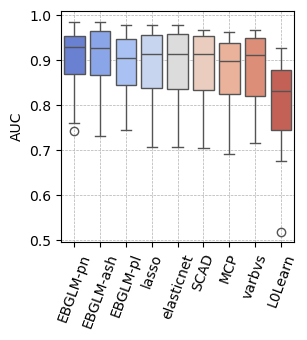

In [178]:

results_df = results_df[results_df['model'].isin(['VEBGLM-point_normal-L-BFGS-B','VEBGLM-ash-L-BFGS-B','VEBGLM-point_laplace-L-BFGS-B','lasso','elasticnet','SCAD','MCP','varbvs','L0Learn'])]
model_order = ['VEBGLM-point_normal-L-BFGS-B','VEBGLM-ash-L-BFGS-B','VEBGLM-point_laplace-L-BFGS-B','lasso','elasticnet','SCAD','MCP','varbvs','L0Learn']
model_labels = ['EBGLM-pn','EBGLM-ash','EBGLM-pl','lasso','elasticnet','SCAD','MCP','varbvs','L0Learn']
plt.figure(figsize=(3, 3))
sns.boxplot(x='model', y='score', data=results_df,order=model_order, palette='coolwarm',whis=1.5, showfliers=True)
plt.xticks(ticks=range(len(model_labels)), labels=model_labels, rotation=70)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylabel('AUC')
plt.xlabel('')
plt.savefig(f'plot/{cate}.pdf', bbox_inches='tight')
plt.show()